# ==============================================================================
# 📊 BUSINESS INSIGHTS DARI EXPLORATORY DATA ANALYSIS
# ==============================================================================
# Bagian ini menjawab pertanyaan bisnis kritis yang ditemukan dari analisis data.
# Insight ini akan membantu stakeholder (Credit Analyst, Risk Manager, dan Management)
# dalam mengambil keputusan strategis terkait kebijakan persetujuan kredit.
# ==============================================================================

Starting NexBank Credit Risk EDA Pipeline...

Dataset berhasil dimuat dari: ../data/loan_data.csv
Dimensi data: 45000 baris, 14 kolom.

 1. ANALISIS STRUKTUR & KESEHATAN DATA

--- Tipe Data Setiap Kolom ---
person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

--- Deteksi Nilai Kosong (Missing Values) ---
Luar biasa! Tidak ada nilai kosong di seluruh kolom dataset.

--- Statistika Deskriptif Kolom Numerik ---
                              count   

C:\Users\User\AppData\Local\Temp\ipykernel_20868\3745933010.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='loan_status', palette=['#2ecc71', '#e74c3c'], ax=ax[0])
C:\Users\User\AppData\Local\Temp\ipykernel_20868\3745933010.py:84: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_xticklabels(['Lancar (0)', 'Gagal Bayar (1)'])


-> Grafik distribusi target disimpan di: plots\01_distribusi_target.png


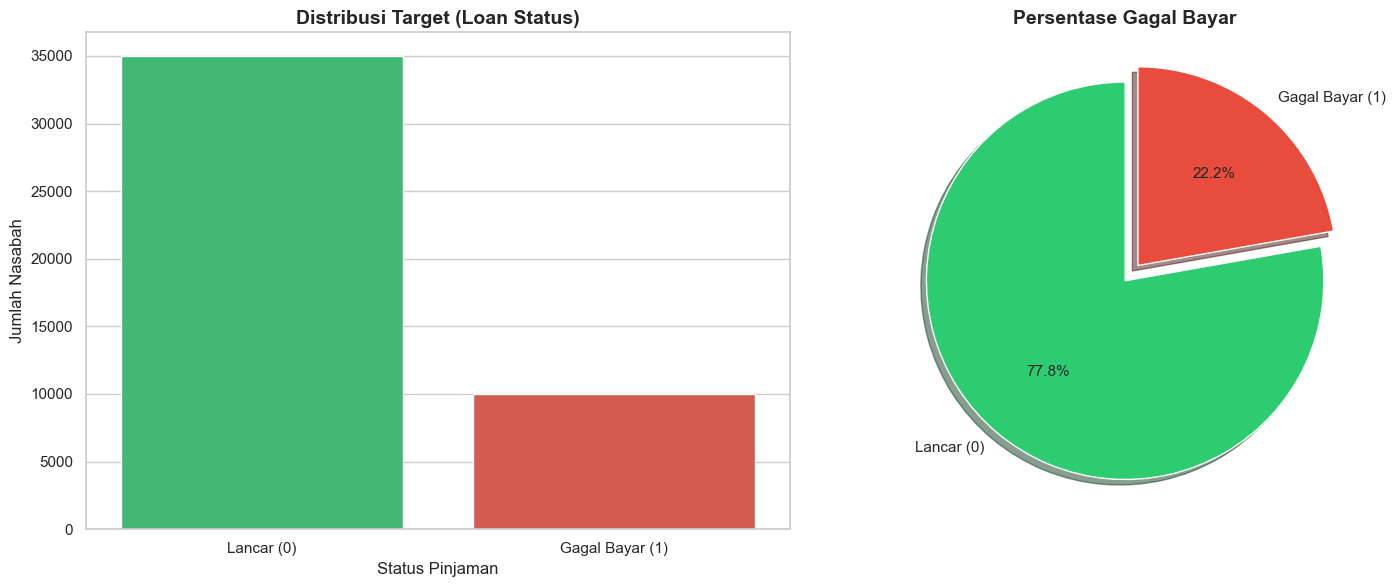


Detail Angka Target:
loan_status
0    35000
1    10000
Name: count, dtype: int64
--------------------------------------------------------------------------------

Menghasilkan Visualisasi: Sebaran Fitur Numerik Utama...
-> Grafik distribusi numerik disimpan di: plots\02_distribusi_numerik.png


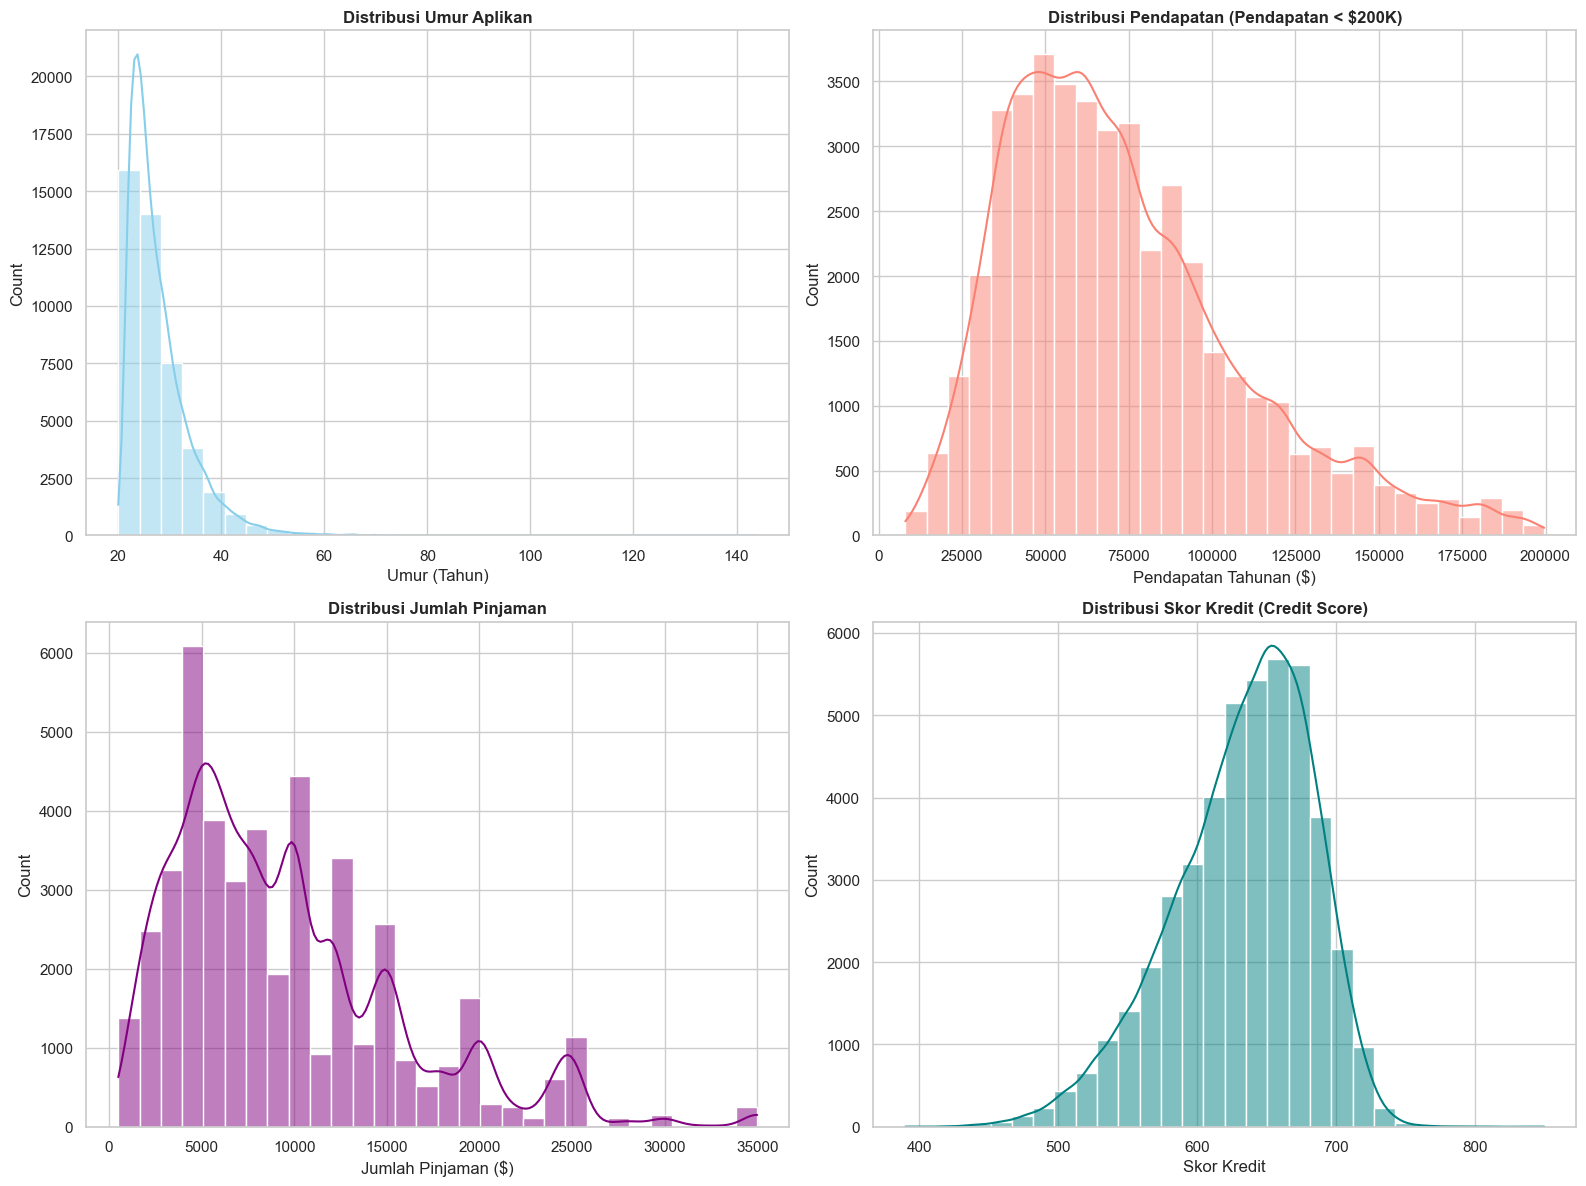

--------------------------------------------------------------------------------

Menghasilkan Visualisasi: Analisis Bivariat Variabel Kategorikal...
-> Grafik analisis bivariat kategorikal disimpan di: plots\03_bivariat_kategorikal.png


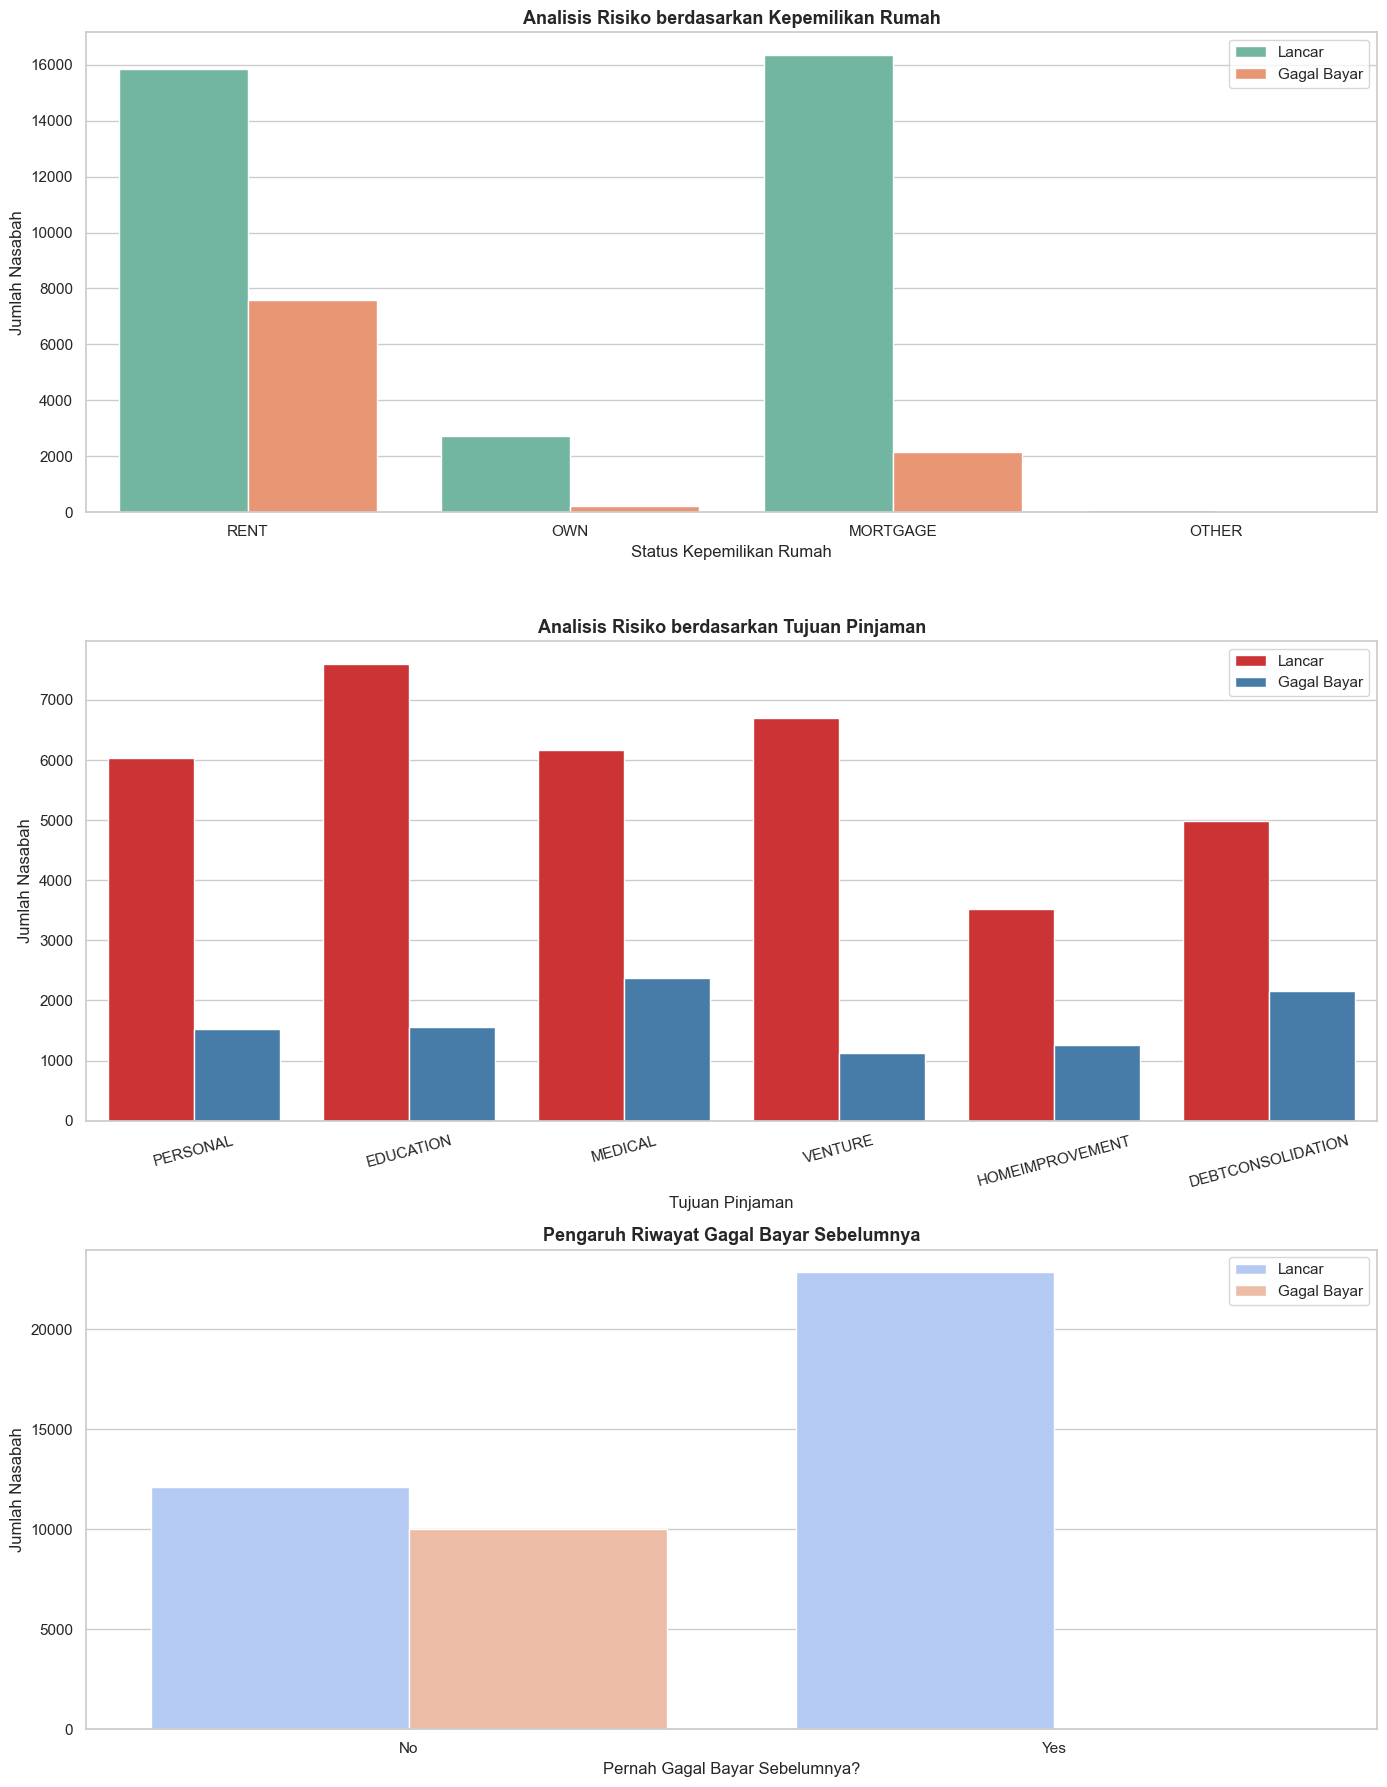

--------------------------------------------------------------------------------

Menghasilkan Visualisasi: Analisis Boxplot Fitur Numerik vs Risiko...


C:\Users\User\AppData\Local\Temp\ipykernel_20868\3745933010.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y='loan_percent_income', palette=['#2ecc71', '#e74c3c'], ax=axes[0, 0])
C:\Users\User\AppData\Local\Temp\ipykernel_20868\3745933010.py:178: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0, 0].set_xticklabels(['Lancar (0)', 'Gagal Bayar (1)'])
C:\Users\User\AppData\Local\Temp\ipykernel_20868\3745933010.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y='loan_int_rate', palette=['#2ecc71', '#e74c3c'], ax=axes[0, 1])
C:\Users\User\AppData\Local\Temp\ipykernel_20868\3745933010.py:184: UserW

-> Grafik perbandingan boxplot disimpan di: plots\04_boxplot_numerik.png


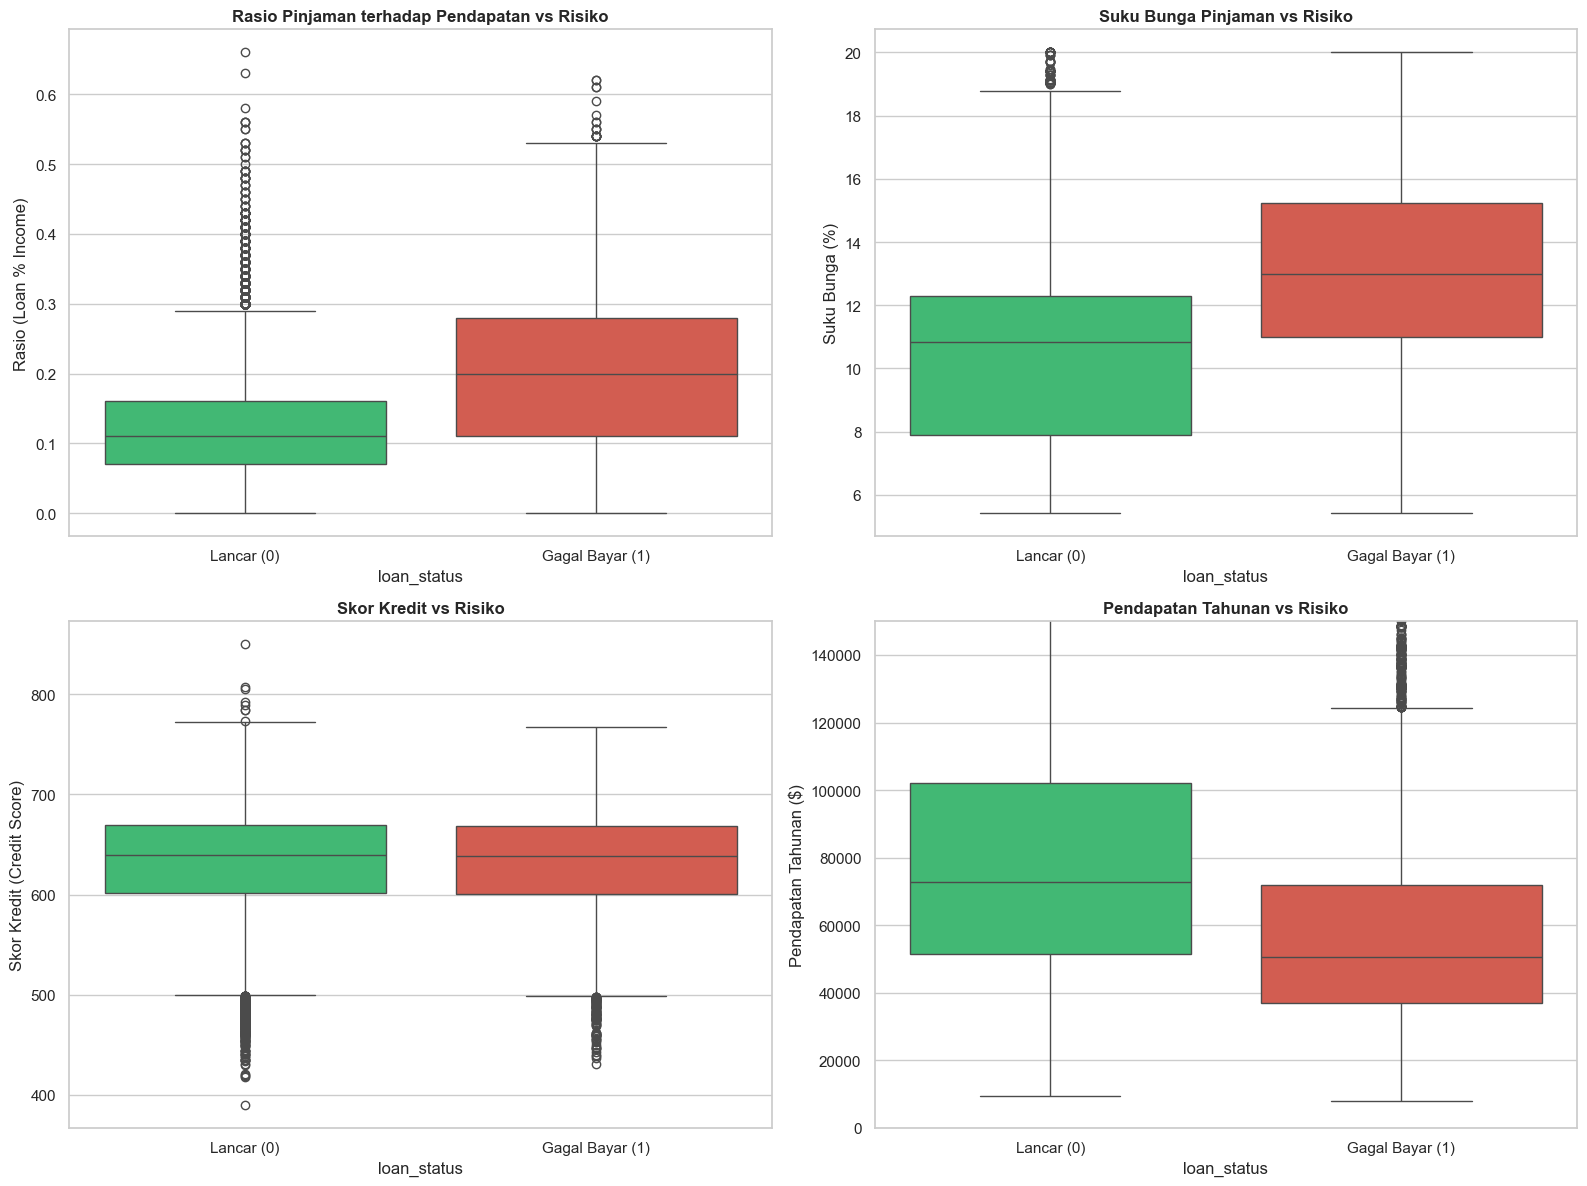

--------------------------------------------------------------------------------

Menghasilkan Visualisasi: Matriks Korelasi Linier...
-> Grafik matriks korelasi disimpan di: plots\05_matriks_korelasi.png


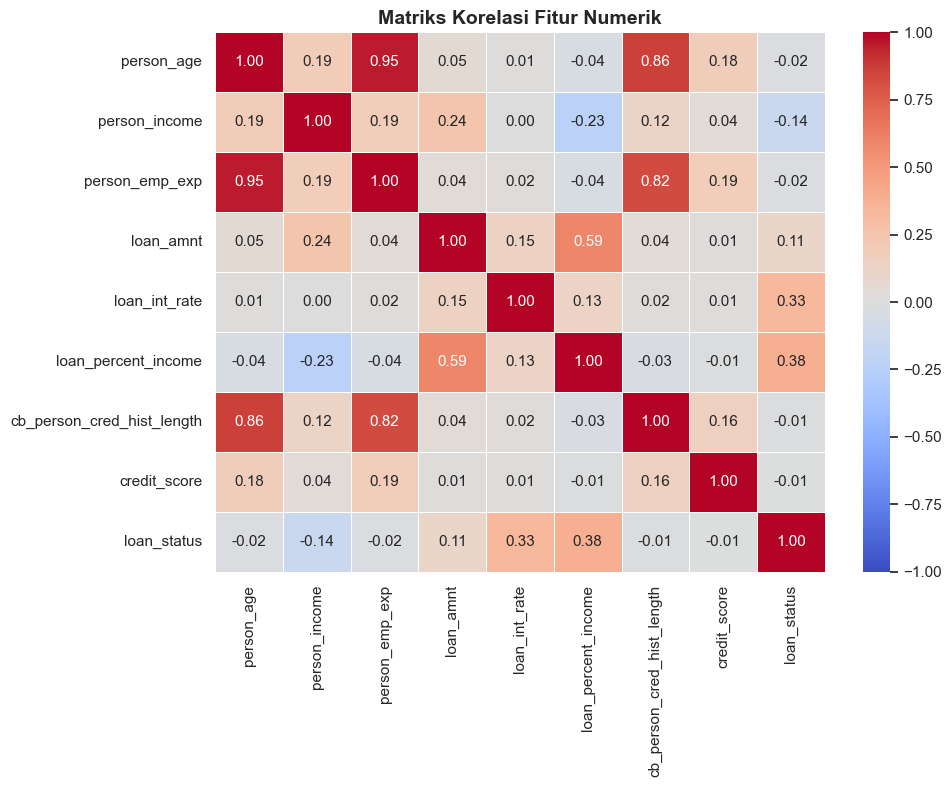

--------------------------------------------------------------------------------

Proses EDA Selesai! Semua grafik visualisasi telah disimpan dengan rapi di dalam folder '/plots'.


In [1]:
# ==============================================================================
# NexBank Credit Decision Engine - Exploratory Data Analysis (EDA) Script
# ==============================================================================
# Skrip ini digunakan untuk menganalisis data historis pinjaman secara mendalam,
# mendeteksi anomali/outlier, memahami korelasi antar-fitur, dan menyimpan
# visualisasi grafis yang dihasilkan ke dalam folder lokal.
# ==============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- KONFIGURASI VISUALISASI ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

def buat_folder_output(nama_folder="plots"):
    """Membuat folder penyimpanan plot jika belum tersedia."""
    if not os.path.exists(nama_folder):
        os.makedirs(nama_folder)
        print(f"Folder '{nama_folder}' berhasil dibuat untuk menyimpan visualisasi.")
    return nama_folder

def load_dataset():
    """Memuat file dataset loan_data.csv dengan pengecekan beberapa jalur alternatif."""
    jalur_pilihan = [
        "../data/loan_data.csv",
        "data/loan_data.csv",
        "loan_data.csv"
    ]
    
    df = None
    for path in jalur_pilihan:
        if os.path.exists(path):
            df = pd.read_csv(path)
            print(f"Dataset berhasil dimuat dari: {path}")
            print(f"Dimensi data: {df.shape[0]} baris, {df.shape[1]} kolom.\n")
            break
            
    if df is None:
        raise FileNotFoundError(
            "Gagal memuat dataset! Pastikan file 'loan_data.csv' berada di folder 'data/' atau di root direktori Anda."
        )
    return df

def analisis_kesehatan_data(df):
    """Memeriksa tipe data, missing values, dan statistika deskriptif awal."""
    print("=" * 80)
    print(" 1. ANALISIS STRUKTUR & KESEHATAN DATA")
    print("=" * 80)
    
    # 1. Informasi tipe data
    print("\n--- Tipe Data Setiap Kolom ---")
    print(df.dtypes)
    
    # 2. Deteksi Missing Values
    print("\n--- Deteksi Nilai Kosong (Missing Values) ---")
    missing_data = df.isnull().sum()
    missing_percent = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Total Missing': missing_data, 'Persentase (%)': missing_percent})
    kolom_kosong = missing_df[missing_df['Total Missing'] > 0]
    
    if len(kolom_kosong) > 0:
        print(kolom_kosong)
    else:
        print("Luar biasa! Tidak ada nilai kosong di seluruh kolom dataset.")
        
    # 3. Statistika deskriptif dasar
    print("\n--- Statistika Deskriptif Kolom Numerik ---")
    print(df.describe().T)
    print("-" * 80)

def plot_univariat_target(df, folder_output):
    """Menganalisis dan memvisualisasikan ketidakseimbangan kelas pada target (loan_status)."""
    print("\nMenghasilkan Visualisasi: Distribusi Target (loan_status)...")
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Countplot (Bar Chart)
    sns.countplot(data=df, x='loan_status', palette=['#2ecc71', '#e74c3c'], ax=ax[0])
    ax[0].set_title('Distribusi Target (Loan Status)', fontsize=14, fontweight='bold')
    ax[0].set_xticklabels(['Lancar (0)', 'Gagal Bayar (1)'])
    ax[0].set_xlabel('Status Pinjaman')
    ax[0].set_ylabel('Jumlah Nasabah')

    # Plot 2: Pie Chart
    target_counts = df['loan_status'].value_counts()
    ax[1].pie(target_counts, labels=['Lancar (0)', 'Gagal Bayar (1)'], autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=[0, 0.1], shadow=True)
    ax[1].set_title('Persentase Gagal Bayar', fontsize=14, fontweight='bold')

    plt.tight_layout()
    path_simpan = os.path.join(folder_output, '01_distribusi_target.png')
    plt.savefig(path_simpan, dpi=300)
    print(f"-> Grafik distribusi target disimpan di: {path_simpan}")
    plt.show()
    
    print("\nDetail Angka Target:")
    print(target_counts)
    print("-" * 80)

def plot_distribusi_numerik(df, folder_output):
    """Menganalisis sebaran distribusi fitur numerik utama."""
    print("\nMenghasilkan Visualisasi: Sebaran Fitur Numerik Utama...")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Distribusi Umur
    sns.histplot(df['person_age'].dropna(), bins=30, kde=True, color='skyblue', ax=axes[0, 0])
    axes[0, 0].set_title('Distribusi Umur Aplikan', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Umur (Tahun)')

    # 2. Distribusi Pendapatan (Dibatasi di bawah $200K agar tidak terdistorsi outlier)
    sns.histplot(df[df['person_income'] < 200000]['person_income'], bins=30, kde=True, color='salmon', ax=axes[0, 1])
    axes[0, 1].set_title('Distribusi Pendapatan (Pendapatan < $200K)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Pendapatan Tahunan ($)')

    # 3. Distribusi Jumlah Pinjaman
    sns.histplot(df['loan_amnt'], bins=30, kde=True, color='purple', ax=axes[1, 0])
    axes[1, 0].set_title('Distribusi Jumlah Pinjaman', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Jumlah Pinjaman ($)')

    # 4. Distribusi Skor Kredit
    sns.histplot(df['credit_score'].dropna(), bins=30, kde=True, color='teal', ax=axes[1, 1])
    axes[1, 1].set_title('Distribusi Skor Kredit (Credit Score)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Skor Kredit')

    plt.tight_layout()
    path_simpan = os.path.join(folder_output, '02_distribusi_numerik.png')
    plt.savefig(path_simpan, dpi=300)
    print(f"-> Grafik distribusi numerik disimpan di: {path_simpan}")
    plt.show()
    print("-" * 80)

def plot_bivariat_kategorikal(df, folder_output):
    """Menganalisis hubungan antara fitur kategorikal dengan status default."""
    print("\nMenghasilkan Visualisasi: Analisis Bivariat Variabel Kategorikal...")
    fig, axes = plt.subplots(3, 1, figsize=(14, 18))

    # 1. Hubungan Kepemilikan Rumah dengan Loan Status
    sns.countplot(data=df, x='person_home_ownership', hue='loan_status', palette='Set2', ax=axes[0])
    axes[0].set_title('Analisis Risiko berdasarkan Kepemilikan Rumah', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Status Kepemilikan Rumah')
    axes[0].set_ylabel('Jumlah Nasabah')
    axes[0].legend(['Lancar', 'Gagal Bayar'])

    # 2. Hubungan Tujuan Pinjaman dengan Loan Status
    sns.countplot(data=df, x='loan_intent', hue='loan_status', palette='Set1', ax=axes[1])
    axes[1].set_title('Analisis Risiko berdasarkan Tujuan Pinjaman', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Tujuan Pinjaman')
    axes[1].set_ylabel('Jumlah Nasabah')
    axes[1].legend(['Lancar', 'Gagal Bayar'])
    axes[1].tick_params(axis='x', rotation=15)

    # 3. Hubungan Riwayat Default Terakhir dengan Loan Status saat ini
    sns.countplot(data=df, x='previous_loan_defaults_on_file', hue='loan_status', palette='coolwarm', ax=axes[2])
    axes[2].set_title('Pengaruh Riwayat Gagal Bayar Sebelumnya', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Pernah Gagal Bayar Sebelumnya?')
    axes[2].set_ylabel('Jumlah Nasabah')
    axes[2].legend(['Lancar', 'Gagal Bayar'])

    plt.tight_layout()
    path_simpan = os.path.join(folder_output, '03_bivariat_kategorikal.png')
    plt.savefig(path_simpan, dpi=300)
    print(f"-> Grafik analisis bivariat kategorikal disimpan di: {path_simpan}")
    plt.show()
    print("-" * 80)

def plot_boxplot_numerik(df, folder_output):
    """Membandingkan karakteristik nilai numerik nasabah lancar vs gagal bayar."""
    print("\nMenghasilkan Visualisasi: Analisis Boxplot Fitur Numerik vs Risiko...")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Hubungan Rasio Pinjaman terhadap Pendapatan (Debt to Income Ratio)
    sns.boxplot(data=df, x='loan_status', y='loan_percent_income', palette=['#2ecc71', '#e74c3c'], ax=axes[0, 0])
    axes[0, 0].set_title('Rasio Pinjaman terhadap Pendapatan vs Risiko', fontsize=12, fontweight='bold')
    axes[0, 0].set_xticklabels(['Lancar (0)', 'Gagal Bayar (1)'])
    axes[0, 0].set_ylabel('Rasio (Loan % Income)')

    # 2. Hubungan Suku Bunga Pinjaman dengan Risiko
    sns.boxplot(data=df, x='loan_status', y='loan_int_rate', palette=['#2ecc71', '#e74c3c'], ax=axes[0, 1])
    axes[0, 1].set_title('Suku Bunga Pinjaman vs Risiko', fontsize=12, fontweight='bold')
    axes[0, 1].set_xticklabels(['Lancar (0)', 'Gagal Bayar (1)'])
    axes[0, 1].set_ylabel('Suku Bunga (%)')

    # 3. Hubungan Skor Kredit dengan Risiko
    sns.boxplot(data=df, x='loan_status', y='credit_score', palette=['#2ecc71', '#e74c3c'], ax=axes[1, 0])
    axes[1, 0].set_title('Skor Kredit vs Risiko', fontsize=12, fontweight='bold')
    axes[1, 0].set_xticklabels(['Lancar (0)', 'Gagal Bayar (1)'])
    axes[1, 0].set_ylabel('Skor Kredit (Credit Score)')

    # 4. Hubungan Pendapatan Tahunan dengan Risiko
    sns.boxplot(data=df, x='loan_status', y='person_income', palette=['#2ecc71', '#e74c3c'], ax=axes[1, 1])
    axes[1, 1].set_title('Pendapatan Tahunan vs Risiko', fontsize=12, fontweight='bold')
    axes[1, 1].set_xticklabels(['Lancar (0)', 'Gagal Bayar (1)'])
    axes[1, 1].set_ylabel('Pendapatan Tahunan ($)')
    axes[1, 1].set_ylim(0, 150000) # Memangkas visualisasi rentang pendapatan ekstrem

    plt.tight_layout()
    path_simpan = os.path.join(folder_output, '04_boxplot_numerik.png')
    plt.savefig(path_simpan, dpi=300)
    print(f"-> Grafik perbandingan boxplot disimpan di: {path_simpan}")
    plt.show()
    print("-" * 80)

def plot_matriks_korelasi(df, folder_output):
    """Mendeteksi hubungan linier (korelasi) antar variabel angka."""
    print("\nMenghasilkan Visualisasi: Matriks Korelasi Linier...")
    
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    corr_matrix = df[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    # PERBAIKAN: Menghapus backslash pengganggu (\") pada argumen fmt agar tidak terjadi SyntaxError
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
    plt.title('Matriks Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    path_simpan = os.path.join(folder_output, '05_matriks_korelasi.png')
    plt.savefig(path_simpan, dpi=300)
    print(f"-> Grafik matriks korelasi disimpan di: {path_simpan}")
    plt.show()
    print("-" * 80)

def deteksi_anomali_outliers(df):
    """Mengecek keberadaan data yang tidak logis (masalah kualitas data)."""
    print("\n" + "=" * 80)
    print(" 2. ANALISIS OUTLIERS & ANOMALI DATA")
    print("=" * 80)
    
    # 1. Cek Umur Tidak Wajar
    print("\n--- Analisis Umur Ekstrem (> 80 Tahun) ---")
    old_customers = df[df['person_age'] > 80]
    print(f"Jumlah nasabah berumur > 80 tahun: {len(old_customers)}")
    if len(old_customers) > 0:
        print(old_customers[['person_age', 'person_income', 'loan_status']].head())
        
    # 2. Cek Pengalaman Kerja Melebihi Logika (Misal > 45 tahun)
    print("\n--- Analisis Pengalaman Kerja Ekstrem (> 45 Tahun) ---")
    emp_col = 'person_emp_exp' if 'person_emp_exp' in df.columns else 'person_emp_length'
    crazy_experience = df[df[emp_col] > 45]
    print(f"Jumlah nasabah dengan lama kerja > 45 tahun: {len(crazy_experience)}")
    if len(crazy_experience) > 0:
        print(crazy_experience[['person_age', emp_col, 'person_income', 'loan_status']].head())
    print("-" * 80)

# --- FUNGSI UTAMA (MAIN RUNNER) ---
if __name__ == "__main__":
    print("Starting NexBank Credit Risk EDA Pipeline...\n")
    
    # 1. Pastikan folder output grafik tersedia
    folder_plots = buat_folder_output("plots")
    
    # 2. Muat dataset
    try:
        data_loan = load_dataset()
    except Exception as e:
        print(f"Error: {e}")
        exit(1)
        
    # 3. Jalankan rangkaian analisis
    analisis_kesehatan_data(data_loan)
    deteksi_anomali_outliers(data_loan)
    
    # 4. Gambar dan simpan grafik visualisasi
    plot_univariat_target(data_loan, folder_plots)
    plot_distribusi_numerik(data_loan, folder_plots)
    plot_bivariat_kategorikal(data_loan, folder_plots)
    plot_boxplot_numerik(data_loan, folder_plots)
    plot_matriks_korelasi(data_loan, folder_plots)
    
    print("\nProses EDA Selesai! Semua grafik visualisasi telah disimpan dengan rapi di dalam folder '/plots'.")